In [1]:
import time, numpy as np, tifffile
from skimage.exposure import equalize_adapthist, rescale_intensity
from cellpose import models

IN_PATH   = "/home/david/EMBL/C1-A3_F1.ome.tiff-A3_F1.ome.tiff-_1-1-1.tiff"   # (T,Y,X) or (T,Y,X,C)
OUT_PATH  = "/home/david/EMBL/manual_labels.tif"
MODEL     = "nuclei"           # "nuclei"/"cyto3" (Cellpose v3, fast on CPU) or "cpsam" (v4, GPU)
USE_GPU   = False              # True only if torch.cuda is available
DIAMETER  = 20                 # ~nucleus diameter px (ignored by cpsam); measure a few
FLOW_THR  = 0.4                # ↑ if over-split, ↓ if nuclei missed
CHANNEL   = None               # RGB/multichannel: channel index for nuclei; None = mean of RGB
USE_CLAHE = True               # local contrast to expose dim nuclei


In [2]:
def to_gray(frame):
    if frame.ndim == 3 and frame.shape[-1] in (3, 4):
        return frame[..., CHANNEL] if CHANNEL is not None else frame[..., :3].mean(-1)
    return frame

def load_stack(path):
    arr = np.squeeze(tifffile.imread(path))
    return arr[None] if arr.ndim == 2 else arr

def load_model():
    if MODEL.lower() == "cpsam":
        try:    return models.CellposeModel(gpu=USE_GPU, pretrained_model="cpsam")
        except TypeError: return models.CellposeModel(gpu=USE_GPU)
    return models.CellposeModel(gpu=USE_GPU, model_type=MODEL)


In [3]:
stack = load_stack(IN_PATH); print("shape:", stack.shape, "| frames:", stack.shape[0])

shape: (81, 894, 894, 3) | frames: 81


shape: (81, 894, 894, 3) | frames: 81


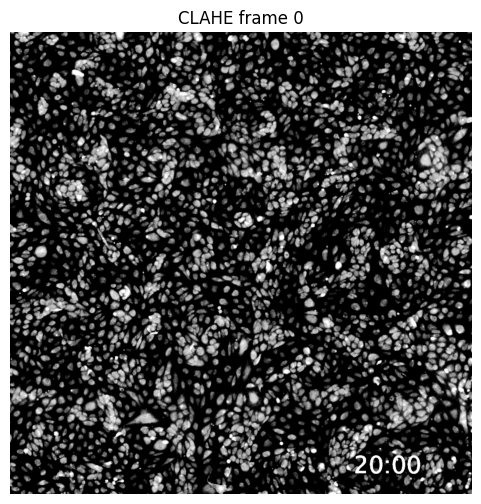

In [ ]:
stack = load_stack(IN_PATH); print("shape:", stack.shape, "| frames:", stack.shape[0])
import matplotlib.pyplot as plt
g0 = equalize_adapthist(rescale_intensity(to_gray(stack[ti]).astype('float32'), out_range=(0,1)),
                        clip_limit=0.04)   # default is 0.01 — higher = more aggressive
plt.figure(figsize=(6,6)); plt.imshow(g0, cmap='gray'); plt.axis('off'); plt.title('CLAHE frame 0');


nuclei in frame 0: 1379


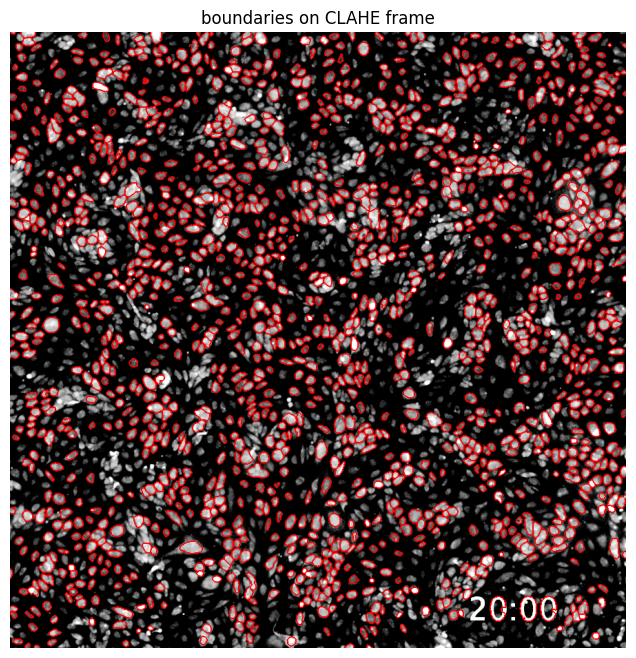

In [ ]:
from skimage.segmentation import find_boundaries
model = load_model(); is_sam = MODEL.lower() == "cpsam"
kw = dict(flow_threshold=0.6, cellprob_threshold=-2.0)   # default cellprob is 0.0
if not is_sam: kw["diameter"] = DIAMETER
m, *_ = model.eval(g0, **kw)
ov = np.dstack([g0]*3); ov[find_boundaries(m)] = [1, 0, 0]
plt.figure(figsize=(8,8)); plt.imshow(ov); plt.axis('off'); plt.title('boundaries on CLAHE frame');


In [6]:
T = stack.shape[0]; H, W = to_gray(stack[0]).shape[:2]
labels = np.zeros((T, H, W), np.int32); t0 = time.time()
for t in range(T):
    g = rescale_intensity(to_gray(stack[t]).astype('float32'), out_range=(0,1))
    if USE_CLAHE: g = equalize_adapthist(g)
    kw = dict(flow_threshold=FLOW_THR); kw.update({} if is_sam else {"diameter": DIAMETER})
    mm, *_ = model.eval(g, **kw); labels[t] = np.asarray(mm, np.int32)
    print(f"frame {t+1}/{T}: {int(labels[t].max())} nuclei  {(time.time()-t0)/(t+1):.1f}s/frame")
tifffile.imwrite(OUT_PATH, labels); print("saved", OUT_PATH, labels.shape)


frame 1/81: 2011 nuclei  19.9s/frame
frame 2/81: 2004 nuclei  19.7s/frame
frame 3/81: 2001 nuclei  20.3s/frame
frame 4/81: 1981 nuclei  19.6s/frame
frame 5/81: 1978 nuclei  19.2s/frame
frame 6/81: 1940 nuclei  19.1s/frame
frame 7/81: 1957 nuclei  18.9s/frame
frame 8/81: 1949 nuclei  18.7s/frame
frame 9/81: 1941 nuclei  18.9s/frame
frame 10/81: 1928 nuclei  19.1s/frame
frame 11/81: 1905 nuclei  19.2s/frame
frame 12/81: 1926 nuclei  19.2s/frame
frame 13/81: 1937 nuclei  19.2s/frame
frame 14/81: 1984 nuclei  19.2s/frame
frame 15/81: 2014 nuclei  19.1s/frame
frame 16/81: 2026 nuclei  19.1s/frame
frame 17/81: 2005 nuclei  19.0s/frame
frame 18/81: 2004 nuclei  19.0s/frame
frame 19/81: 2021 nuclei  19.0s/frame
frame 20/81: 1945 nuclei  19.0s/frame


KeyboardInterrupt: 